## Preprocesamiebnto de los datos para Machine Learning
aplicar las tecnicad principales de prepocesamineto de datos para preparar un dataset antes del entrenamiento 


In [1]:
import sys
print(sys.executable)

C:\Users\elzvm\anaconda3\python.exe


In [2]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [3]:
import sklearn
print(sklearn.__version__)

1.7.2


In [4]:
!where python

C:\Users\elzvm\anaconda3\python.exe
C:\Users\elzvm\AppData\Local\Microsoft\WindowsApps\python.exe


In [5]:
# Importamos las librerías
import pandas as pd
import numpy as np

# Librerías de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Librerías para graficar
import seaborn as sns
import matplotlib.pyplot as plt

# Librería de Kaggle
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


## Parte 1. comprension del problema
Trabajaremos con el Dataset del Titanid, para construir un modelo que sea capaz de predecir si una persona sobrevive o no

In [6]:
#Descargamos el Dataset de la pagina Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path ## imprimimos la ruta 

'C:\\Users\\elzvm\\.cache\\kagglehub\\datasets\\yasserh\\titanic-dataset\\versions\\1'

In [7]:
dfTitanic= pd.read_csv(path +"/Titanic-Dataset.csv")##Creamos el Dataframe


In [8]:
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Parte 2. Seleccion de valores predictoras y variable objetivo
La variable objetivo sera: Survived
donde 0 = No sobrevivió 1 = Sobrevivió

In [10]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [11]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [12]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [13]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlación e Hipótesis
Vamos a identificar la relación entre variables númericas.
nota: La correlacion NO representa la importancia REAL de la variable en el modelo.

In [14]:
variables_numericas = [
    "Survived",
    "Pclass",
    "SibSp",
    "Parch",
    "Fare"
]

In [15]:
corr = dfTitanic[variables_numericas].corr() #Creamos la matriz de correlación
corr

,Survived,Pclass,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.083081,0.018443,-0.549500
SibSp,-0.035322,0.083081,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.159651,0.216225,1.000000


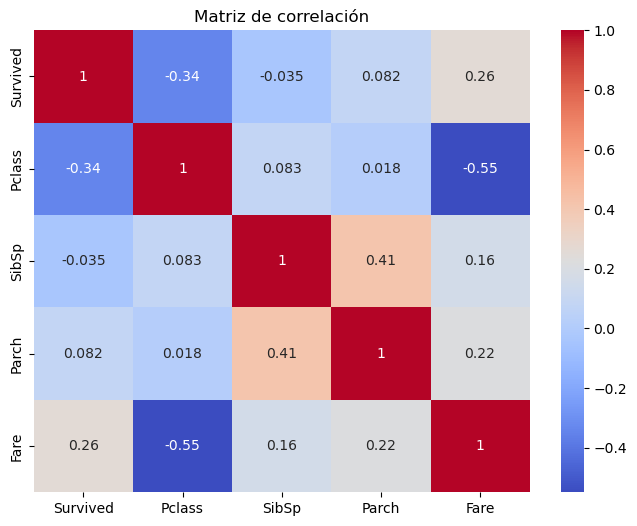

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlación")
plt.show()

### Parte 4. Variables predictoras.
x --> Aquellas variables que nos ayudan a predecir 
y --> Variable objetivo

In [17]:
dfTitanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [18]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]

In [19]:
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [20]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

In [21]:
y.name

'Survived'

# Parte 5. Limpieza de los datos
Realizaremos la imputación de los datos, donde existan valores nulos.

In [22]:
# Revisamos si existen valores nulos
X.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [23]:
# Vamos a imputar los datos para el campo Edad, calcula la mediana
X = X.copy()

X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

In [24]:
# Vamos imputar los datos para el campo Embarked, calculando la moda
X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

In [25]:
# Revisamos si existen valores nulos
X.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

## Parte 6; Normalizamos los datos categoricos (texto)
Los algoritmos de ML no entienden texto.

In [26]:
X.head(2)

,Pclass,Sex,Age,Fare,Embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C


In [27]:
# One Hot Encoding
X = pd.get_dummies(
    X,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first=True
)

In [28]:
X.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


# Parte 7. División de los datos
No debemos entrenar y evaluar utilizando los mismos datos
80% para entrenar y 20% para evaluar 

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
print("Entrenamiento X:", X_train.shape)

Entrenamiento X: (712, 6)


In [31]:
print("Prueba X:", X_test.shape)

Prueba X: (179, 6)


In [32]:
print("Entrenamiento y:", y_train.shape)

Entrenamiento y: (712,)


In [33]:
print("Prueba y:", y_test.shape)

Prueba y: (179,)


## ESCALADO DE LOS DATOS
LAS VARIABLES NUMERICAS TIENEN VALORES DISTINTOS EL ESCALADO EVITA QUE LAS VARIABLES CON MAYORES VALORES DOMINEN EL APRENDIZAJE DEL MODELO

In [34]:
columnas_numericas = [
"Age",
"Fare"
]

In [35]:
X_train[columnas_numericas].describe()

,Age,Fare
count,712.000000,712.000000
mean,29.204129,32.586276
std,13.007971,51.969529
min,0.420000,0.000000
25%,22.000000,7.925000
50%,28.000000,14.454200
75%,35.000000,30.500000
max,80.000000,512.329200


In [36]:
## ESCALAMOS LOS DATOS USANDO STANDARSCALER
scaler = StandardScaler()

In [37]:
X_train.loc[:, columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test.loc[:, columnas_numericas] = scaler.transform(X_test[columnas_numericas])

In [38]:
X_train[columnas_numericas].describe()

,Age,Fare
count,7.120000e+02,7.120000e+02
mean,1.746418e-17,5.363999e-17
std,1.000703e+00,1.000703e+00
min,-2.214363e+00,-6.274674e-01
25%,-5.542135e-01,-4.748670e-01
50%,-9.263364e-02,-3.491435e-01
75%,4.458762e-01,-4.017244e-02
max,3.907725e+00,9.237724e+00


In [39]:
## ESCALAMOS PARA QUE LOS DATOS NO SEAN DISCRIMINADOS

## ENTRENAMIENTO DEL ALGORTIMO ARBOL DE DECISION:
permite clasificar los registros con respecto  a las variables

In [40]:
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [41]:
modelo.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## EVALUAMOS LA EFICIA DEL MODELO 
REALIZAMOS PREDICCIONES SOBRE EL CONJUNTO DE PRUEBA, PARA CALCULAR LA EXACTITUD DEL MODELO

In [42]:
# Invocamos el modelo
prediccion = modelo.predict(
    X_test
)

In [43]:
pd.DataFrame(
    {
        "Survived Real: " : y_test,
        "Survived Predicha: " : prediccion
    }
).head(20)

,Survived Real:,Survived Predicha:
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


## Evaluación del modelo
Utilizaremos el accuracy para determinar el porcentaje de predicciones correctas realizadas por el modelo

In [44]:
accuracy = accuracy_score(y_test, prediccion)

In [45]:
print(f"La exactitud del modelo es: {accuracy:.4f}")

La exactitud del modelo es: 0.7989


In [46]:
from sklearn.metrics import classification_report

In [47]:
print(classification_report(y_test, prediccion))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       105
           1       0.84      0.64      0.72        74

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

